# LLE for Lorenz system

# Load Packages

In [1]:
from math import log2, ceil
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.signal import periodogram
import FunctionLE as Fn


# Generate Lorenz Data

In [2]:
#%% Generate Lorenz
def lorenz_system(t, state, sigma, rho, beta):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

# Parameters
sigma = 16 #10#16
rho =45.92# 28# 45.92
beta =4# 8/3 #4

# Initial conditions
initial_state = [1.0, 1.0, 1.0]

# Time span
t_start = 0.0
t_end = 100
num_points = 10000
t_span = np.linspace(t_start, t_end, num_points)
dt = (t_end-t_start)/num_points
print(f"dt={dt}")

# Solve the differential equations
solution = solve_ivp(lorenz_system, [t_start, t_end], initial_state,
                     args=(sigma, rho, beta), t_eval=t_span)

# Extract the solution
x_values = solution.y[0]
y_values = solution.y[1]
z_values = solution.y[2]

dt=0.01


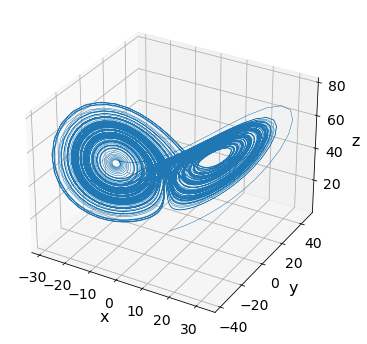

In [3]:
# Plot the attractor (Lorenz butterfly)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x_values, y_values, z_values, lw=0.5)
ax.set_xlabel('x', fontsize=16)
ax.set_ylabel('y', fontsize=16)
ax.set_zlabel('z', fontsize=16)
#ax.set_title('Lorenz Attractor')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='z', labelsize=14)
plt.show()

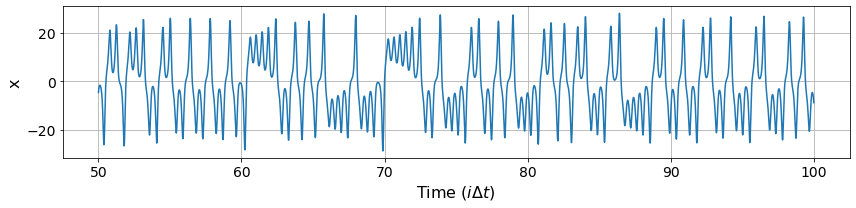

In [4]:
# Plot the data for LLE algorithm
fig, ax = plt.subplots(1,figsize=(12,3), tight_layout=True)
ax.plot(t_span[5000:], x_values[5000:])
ax.set_xlabel('Time $(i \Delta t)$', fontsize=16)
ax.set_ylabel('x', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.grid()
plt.show()


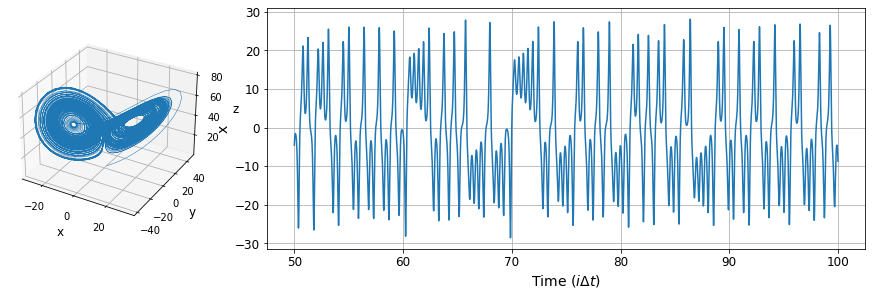

In [8]:
# plot attractor and x-observations for LLE
fig = plt.figure(figsize=(12,4), constrained_layout=True)
gs = fig.add_gridspec(1, 4)  # 1 row, 4 columns

# 3D Lorenz attractor takes 1 column (1/4 width)
ax0 = fig.add_subplot(gs[0, 0], projection='3d')
ax0.plot(x_values, y_values, z_values, lw=0.5)
ax0.set_xlabel('x', fontsize=12)
ax0.set_ylabel('y', fontsize=12)
ax0.set_zlabel('z', fontsize=12)
ax0.tick_params(axis='x', labelsize=10)
ax0.tick_params(axis='y', labelsize=10)
ax0.tick_params(axis='z', labelsize=10)
#ax0.set_title('Lorenz Attractor', fontsize=12)

# Time series plot takes 3 columns (3/4 width)
ax1 = fig.add_subplot(gs[0, 1:])
ax1.plot(t_span[5000:], x_values[5000:])
ax1.set_xlabel('Time $(i \Delta t)$', fontsize=14)
ax1.set_ylabel('x', fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.grid(True)
#ax1.set_title('Lorenz Time Series', fontsize=12)

plt.show()

In [5]:
# select data for LLE algorithm
x_obs = x_values[5000:] 

# Cao's Algorithm for Embedding Dimension

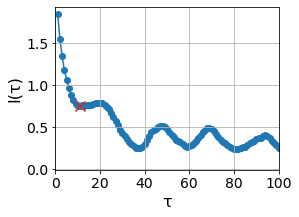

In [ ]:
## Find tau from mutual information
Sturges = ceil(log2(len(x_obs)) +1)
Sturges

taus = range(1,501)
num_bins = Sturges
mi_values = [Fn.mutual_information(x_obs, num_bins, tau) for tau in taus]

# Plot mutual information
fig, ax =plt.subplots(1, figsize=(4,3))
ax.plot(taus, mi_values, marker='o', zorder=1)
ax.set_xlabel('τ', fontsize=16)
ax.set_ylabel('I(τ)', fontsize=16)
ax.grid()
ax.set_xlim(0,100)
ax.scatter(taus[10], mi_values[10], marker='x', color='tab:red', s=100, zorder=3)
#.title('Mutual Information I(τ) vs. Time Delay τ')
ax.tick_params(axis='both', which='major', labelsize=14)
plt.show()

In [8]:
# Find the first local minimum
for i in range(1, len(mi_values) - 1):
    if mi_values[i] < mi_values[i - 1] and mi_values[i] < mi_values[i + 1]:
        first_local_min_tau = taus[i]
        first_local_min_value = mi_values[i]
        break
tau = first_local_min_tau
print(f"The first local minimum occurs at τ = {tau} with I(τ) = {first_local_min_value}")

The first local minimum occurs at τ = 11 with I(τ) = 0.7420493354040772


In [43]:
# Using Cao's method to find the optimal embedding dimension
time_delay = tau
max_m = 20
E, E_star = Fn.cao_method(x_obs, 21, tau)

E1 = Fn.E1_ratio(E)
E2 = Fn.E2_ratio(E_star)

m = 1
shape of X_m (1, 5000)
shape of X_m+1 (2, 4989)
4999
t= 0 t_prime= 2265
t= 1 t_prime= 4887
t= 2 t_prime= 2575
t= 3 t_prime= 4160
t= 4 t_prime= 3040
t= 5 t_prime= 381
t= 6 t_prime= 1942
t= 7 t_prime= 2674
t= 8 t_prime= 1966
t= 9 t_prime= 4890
t= 10 t_prime= 155
t= 11 t_prime= 2260
t= 12 t_prime= 3280
t= 13 t_prime= 3044
t= 14 t_prime= 4565
t= 15 t_prime= 4154
t= 16 t_prime= 158
t= 17 t_prime= 1399
t= 18 t_prime= 3188
t= 19 t_prime= 978
t= 20 t_prime= 521
t= 21 t_prime= 3222
t= 22 t_prime= 4345
t= 23 t_prime= 664
t= 24 t_prime= 2300
t= 25 t_prime= 4302
t= 26 t_prime= 2685
t= 27 t_prime= 344
t= 28 t_prime= 2923
t= 29 t_prime= 1847
t= 30 t_prime= 1015
t= 31 t_prime= 3726
t= 32 t_prime= 173
t= 33 t_prime= 4971
t= 34 t_prime= 3540
t= 35 t_prime= 3539
t= 36 t_prime= 1020
t= 37 t_prime= 181
t= 38 t_prime= 178
t= 39 t_prime= 178
t= 40 t_prime= 3536
t= 41 t_prime= 3208
t= 42 t_prime= 822
t= 43 t_prime= 3440
t= 44 t_prime= 2930
t= 45 t_prime= 2927
t= 46 t_prime= 3794
t= 47 t_prime= 4118
t= 

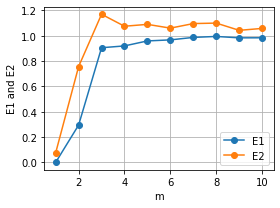

In [54]:
m_values = np.arange(1,21)
fig, ax = plt.subplots(1, figsize=(4,3), tight_layout=True)
ax.plot(m_values[:10], E1[:10], label='E1', marker='o')
ax.plot(m_values[:10], E2[:10], label='E2', marker='o')
ax.grid()
ax.legend()
ax.set_xlabel('m')
ax.set_ylabel('E1 and E2')
ax.set_xlim(0.5, 10.5)
plt.show()

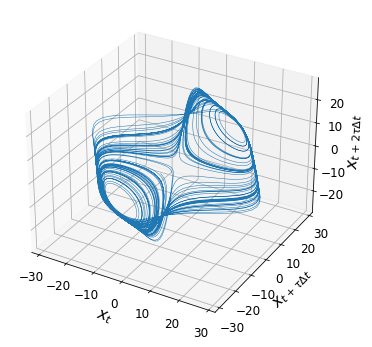

In [ ]:
# Choose embedding dimension and time delay
m_embed = 3  # for example, from E1 plateau
tau_embed = tau  # use the tau you found from mutual information

# Construct delay-coordinate vectors
N_vectors = len(x_obs) - (m_embed - 1) * tau_embed
X_embedded = np.zeros((N_vectors, m_embed))

for i in range(m_embed):
    X_embedded[:, i] = x_obs[i*tau_embed : i*tau_embed + N_vectors]

# Plot the reconstructed attractor in 3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(X_embedded[:,0], X_embedded[:,1], X_embedded[:,2], lw=0.5)
ax.set_xlabel(r'$x_t$', fontsize=16)
ax.set_ylabel(r'$x_{t+\tau\Delta t}$', fontsize=16)
ax.set_zlabel(r'$x_{t+2\tau\Delta t}$', fontsize=16)
#ax.set_title(f'Reconstructed Lorenz Attractor (m={m_embed}, tau={tau_embed})')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='z', labelsize=12)
plt.show()

# LLE using Rosenstein's algorithm

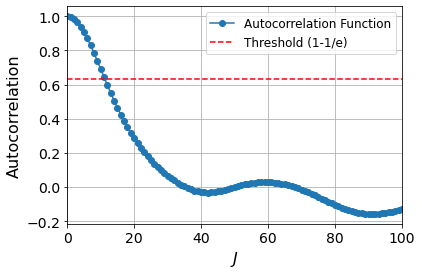

In [10]:
# find J for completeness could also just use tau found from autocorrelation
autocorr_result = np.correlate(x_obs-np.mean(x_obs), x_obs-np.mean(x_obs), mode='full')
autocorr = autocorr_result[len(autocorr_result) // 2:]
autocorr /= autocorr[0] #normalise by autocorrelation at lag 0

# Find the lag (embedding delay) where the autocorrelation drops below 1 - 1/e of its initial value
threshold = 1 - 1/np.exp(1)  # 1 - 1/e is approximately 0.632

lags = np.arange(len(autocorr))
fig, ax =plt.subplots(1, figsize=(6,4))
ax.plot(lags, autocorr, marker='o', label='Autocorrelation Function')
ax.set_xlim(0,100)
ax.axhline(y=threshold, color='red', linestyle='--', label='Threshold (1-1/e)')
ax.grid()
ax.set_xlabel(r'$J$', fontsize=16)
ax.set_ylabel('Autocorrelation', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.legend(fontsize=12)

In [11]:
#%% Rosenstein's Algorithm for LLE
J_value = Fn.J_from_autocorrelation(x_obs)
J_value

12

In [ ]:
# LLE
ts = x_obs[:2000]
J = J_value
m = 3
t_end = 700
N = len(ts)
M = N - (m - 1) * J
X = np.full((M, m), np.nan)
for i in range(M):
    idx = np.arange(i, i + (m - 1) * J + 1, J)
    X[i, :] = ts[idx]

j = Fn.get_nearest_neighbours(X, mu=Fn.mean_period(ts))
valid_indices = [i for i in range(M) if i + t_end < M and j[i] + t_end < M]
num_valid = len(valid_indices)

distance_log_i = np.zeros((num_valid, t_end + 1))
for idx, i in enumerate(valid_indices):
    distances = np.array([Fn.distance(X[i + k], X[j[i] + k]) for k in range(t_end + 1)])
    distance_log_i[idx, :] = np.log(distances)

mean_log_distance = np.mean(distance_log_i, axis=0)
time_innovation = np.arange(t_end + 1)

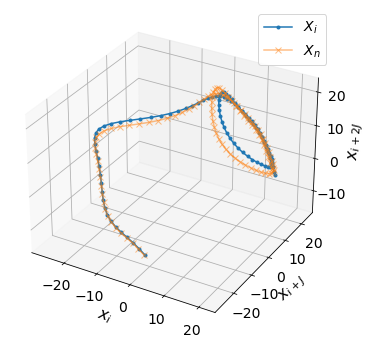

In [ ]:
example_i = valid_indices[125]  # pick the first valid index
example_j = j[example_i]
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
t_end = 100
ax.plot(X[example_i:example_i + t_end + 1, 0],
            X[example_i:example_i + t_end + 1, 1], 
            X[example_i:example_i + t_end + 1, 2],
            color='tab:blue', marker='.', linestyle='-', label=r'$X_i$')
ax.plot(X[example_j:example_j + t_end + 1, 0],
            X[example_j:example_j + t_end + 1, 1], 
            X[example_j:example_j + t_end + 1, 2],
            color='tab:orange', marker='x',  linestyle='-', alpha=0.5, label=r'$X_n$')

ax.set_xlabel(r'$x_i$', fontsize=16)
ax.set_ylabel(r'$x_{i+J}$', fontsize=16)
ax.set_zlabel(r'$x_{i+2J}$', fontsize=16)
#ax.set_title('Lorenz Attractor')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='z', labelsize=14)
ax.legend(fontsize=14)
plt.show()

In [ ]:
# LLE
J = J_value
m = 3
t_end = 700
time_innovation, mean_log_distance, distance_log_i = Fn.lyap(x_obs, J, m, t_end)


J: 12, m: 3, N: 5000, M: 4976
finding nearest neighbours...
computing distances through time


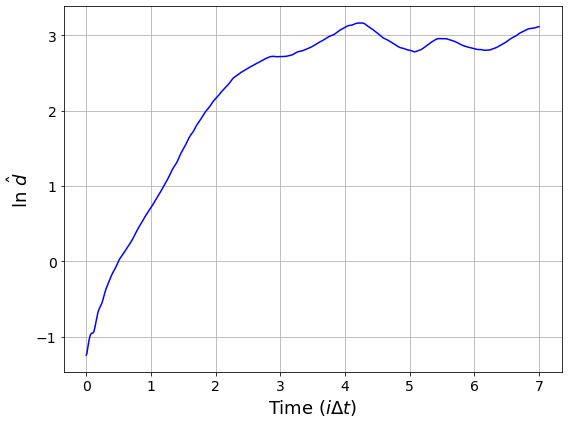

In [ ]:
time_values = time_innovation*dt
fig, ax = plt.subplots(1,figsize=(8,6), tight_layout=True)
ax.plot(time_values, mean_log_distance[:], 'b-')
ax.set_xlabel('Time $(i\Delta t)$', fontsize=18)
ax.set_ylabel('ln $\hat{d}$', fontsize=18)
#plt.title('Mean Log Distance over Time')
ax.grid()
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
#ax.set_xlim(-10,200)
plt.show()


0 239
1.5090861492317007


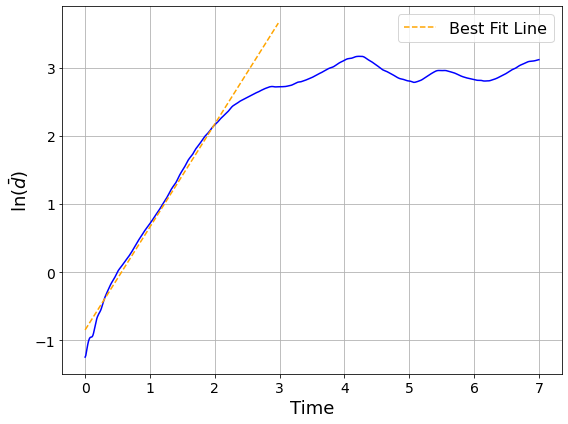

LLE = 1.5090861492317007
Lyapunov Time = 0.6626526924981159


In [ ]:
# fit line of best fit
slope_start = int(0//dt) # change here for start of linear slope
slope_end =int(2.4//dt) #change here for end of linear slope
print(slope_start, slope_end)
slope, intercept, r_value, p_value, std_err = linregress(time_values[slope_start:slope_end], mean_log_distance[slope_start:slope_end])
print(slope)

end_val = int(3//dt)
best_fit = slope*time_values[:end_val] + intercept
fig, ax = plt.subplots(1,figsize=(8,6), tight_layout=True)
ax.plot(time_values[:], mean_log_distance[:], 'b-')
ax.plot(time_values[:end_val], best_fit, linestyle='--', color='orange', label='Best Fit Line')
ax.set_xlabel('Time', fontsize=18)
ax.set_ylabel(r'$\ln(\bar{d})$', fontsize=18)
#plt.title('Mean Log Distance over Time')
ax.grid()
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
#plt.title('Mean Log Distance over Time')
ax.legend(fontsize=16)
#ax.set_xlim(-10,200)
#ax.set_ylim(-7,-5)
plt.show()

print('LLE =', slope)
print('Lyapunov Time =', 1/slope)
plt.show()